# Segmentación de clientes de comercio electrónico con K Means

**Proyecto final de aprendizaje no supervisado**  
**Integrantes:**
   
    -Culqui Goyzueta Jose Eduardo
    -Valdivia Mosqueira
    -Villanueva Mendoza Rosselly
**Curso:** Sistemas Inteligentes
**Institución:** Universidad Nacional de Cajamarca  


Se utiliza el conjunto **Online Retail** del UCI Machine Learning Repository y se construye una representación RFM de cada cliente.


## 1 Enunciado del problema

Una empresa de comercio electrónico registra cientos de miles de transacciones, pero el archivo transaccional no contiene una etiqueta que indique a qué tipo de cliente pertenece cada comprador. Analizar a todos los clientes como si fueran iguales limitaría la capacidad de reconocer compradores frecuentes, clientes recientes, consumidores de alto valor y clientes inactivos.

El problema consiste en **descubrir grupos naturales de clientes con comportamientos de compra semejantes**. Para representar ese comportamiento se emplean tres variables del modelo RFM:

- **Recency:** días transcurridos desde la última compra.
- **Frequency:** número de facturas de compra diferentes.
- **Monetary:** importe total gastado por el cliente.

El enfoque es no supervisado porque no existe una variable objetivo que proporcione el segmento correcto. El algoritmo debe identificar la estructura a partir de similitudes y diferencias entre los valores RFM.



## 2 Etapas del laboratorio

El proceso se organiza de acuerdo con la guía del proyecto. Todas las decisiones se ejecutan de forma reproducible y se fijan semillas aleatorias cuando corresponde.

### Ejecución del proyecto completo
Ejecuta las celdas en orden desde el principio. En Jupyter instala las dependencias con la siguiente celda si faltan; en Colab también puede utilizarse. La descarga de UCI requiere conexión a Internet. Al finalizar se crea `proyecto_streamlit_online_retail.zip` con la app, el modelo y sus datos de consulta.

**Capturas del informe:** cada nueva celda de código tiene un identificador `C26`, `C27`, etc. Captura desde ese comentario hasta el final de la celda, junto con la salida indicada en el Word. Los resultados son históricos; Recency se calcula respecto al 10/12/2011, no respecto a hoy.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 83.1 MB/s eta 0:00:00


## 2.1 Carga del dataset

In [2]:
#En esta primera etapa importamos las librerías necesarias
#para cargar y manipular los datos, generar gráficos y aplicar K-Means.
from pathlib import Path
from urllib.request import urlopen
import io
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

SEED = 42
UCI_URL = "https://archive.ics.uci.edu/static/public/352/online%2Bretail.zip"
OUTPUT_DIR = Path("salidas_online_retail")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = ["#1F4E78", "#2E75B6", "#70AD47", "#ED7D31"]

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [3]:
#CARGA DEL DATASET:
# Se busca primero el archivo Online Retail de forma local y, si no está disponible,
# se descarga automáticamente desde la fuente oficial de UCI. Finalmente, se carga
# el archivo en un DataFrame y se realiza una primera inspección de sus dimensiones y registros.
candidates = [
    Path("data_online_retail/Online Retail.xlsx"),
    Path("data/Online Retail.xlsx"),
    Path("Online Retail.xlsx"),
    Path("/content/Online Retail.xlsx"),
]

xlsx_path = next((path for path in candidates if path.exists()), None)

if xlsx_path is None:
    data_dir = Path("data")
    data_dir.mkdir(exist_ok=True)
    print("Descargando el dataset oficial de UCI...")
    with urlopen(UCI_URL, timeout=180) as response:
        zip_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as archive:
        archive.extractall(data_dir)
    xlsx_path = data_dir / "Online Retail.xlsx"

df_raw = pd.read_excel(xlsx_path)

print(f"Archivo utilizado: {xlsx_path}")
print(f"Dimensiones iniciales: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas")
display(df_raw.head())

Descargando el dataset oficial de UCI...
Archivo utilizado: data/Online Retail.xlsx
Dimensiones iniciales: 541,909 filas y 8 columnas


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


### Descripción de las variables originales

| Variable | Tipo | Interpretación |
|---|---|---|
| InvoiceNo | Categórica | Código de factura; los códigos que empiezan con C representan cancelaciones |
| StockCode | Categórica | Código del producto |
| Description | Categórica | Nombre o descripción del producto |
| Quantity | Numérica | Cantidad comprada dentro de la transacción |
| InvoiceDate | Fecha y hora | Momento de generación de la factura |
| UnitPrice | Numérica | Precio unitario en libras esterlinas |
| CustomerID | Categórica | Identificador del cliente |
| Country | Categórica | País de residencia del cliente |



In [4]:
# Se obtiene una visión general de los datos: cantidad de registros, facturas,
# productos, clientes, países y periodo de tiempo que abarca el dataset.

# IMPORTANTE: también se revisan los tipos de datos de cada variable
# para verificar cómo fueron interpretados al cargar el archivo.
initial_summary = pd.DataFrame({
    "Indicador": [
        "Filas",
        "Columnas",
        "Facturas únicas",
        "Productos únicos",
        "Clientes identificados",
        "Países",
        "Fecha inicial",
        "Fecha final",
    ],
    "Valor": [
        f"{len(df_raw):,}",
        df_raw.shape[1],
        f"{df_raw['InvoiceNo'].nunique():,}",
        f"{df_raw['StockCode'].nunique():,}",
        f"{df_raw['CustomerID'].nunique():,}",
        df_raw["Country"].nunique(),
        df_raw["InvoiceDate"].min(),
        df_raw["InvoiceDate"].max(),
    ],
})
display(initial_summary)
print("Tipos de datos:")
display(df_raw.dtypes.rename("Tipo").to_frame())

,Indicador,Valor
0,Filas,"541,909"
1,Columnas,8
2,Facturas únicas,"25,900"
3,Productos únicos,"4,070"
4,Clientes identificados,"4,372"
5,Países,38
6,Fecha inicial,2010-12-01 08:26:00
7,Fecha final,2011-12-09 12:50:00


Tipos de datos:


,Tipo
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


## 2.2 Análisis exploratorio de datos EDA

In [5]:
# Se identifican problemas que deberán tratarse antes del modelado:
# valores nulos, duplicados, cancelaciones y cantidades o precios no positivos.
quality = pd.DataFrame({
    "Tipo": df_raw.dtypes.astype(str),
    "Nulos": df_raw.isna().sum(),
    "Porcentaje_nulos": (df_raw.isna().mean() * 100).round(2),
    "Valores_unicos": df_raw.nunique(dropna=True),
})

print(f"Filas duplicadas exactas: {df_raw.duplicated().sum():,}")
print(f"Facturas de cancelación: {df_raw['InvoiceNo'].astype(str).str.upper().str.startswith('C').sum():,}")
print(f"Registros con cantidad <= 0: {(df_raw['Quantity'] <= 0).sum():,}")
print(f"Registros con precio <= 0: {(df_raw['UnitPrice'] <= 0).sum():,}")
display(quality)

Filas duplicadas exactas: 5,268
Facturas de cancelación: 9,288
Registros con cantidad <= 0: 10,624
Registros con precio <= 0: 2,517


,Tipo,Nulos,Porcentaje_nulos,Valores_unicos
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[ns],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


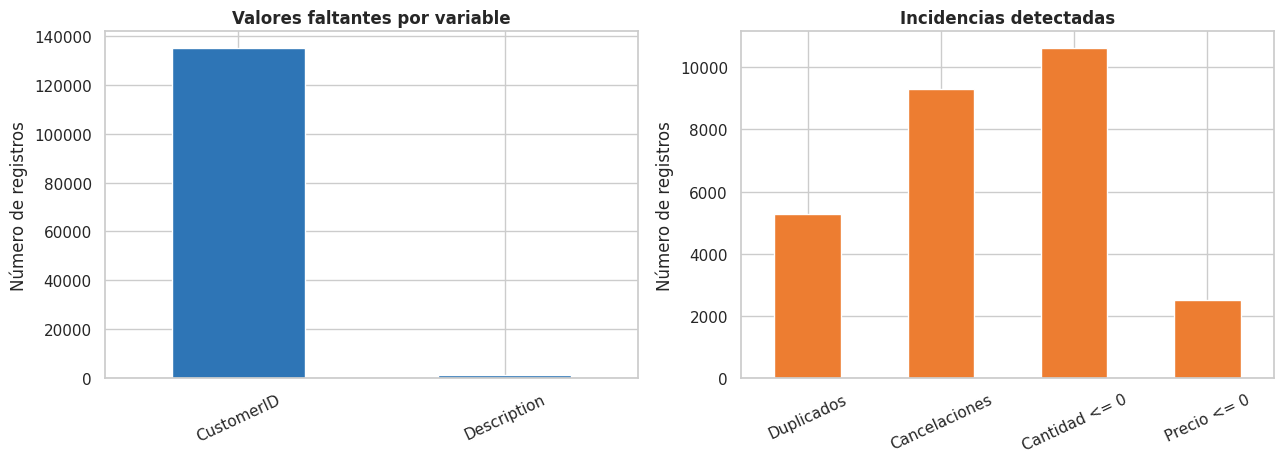

In [6]:
# VISUALIZACIÓN DE LA CALIDAD DE LOS DATOS:
# Se representan gráficamente los valores faltantes y las principales incidencias
# detectadas: duplicados, cancelaciones y valores no positivos.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

null_counts = df_raw.isna().sum().sort_values(ascending=False)
null_counts[null_counts > 0].plot(
    kind="bar", ax=axes[0], color="#2E75B6", edgecolor="white"
)
axes[0].set_title("Valores faltantes por variable", weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de registros")
axes[0].tick_params(axis="x", rotation=25)

issue_counts = pd.Series({
    "Duplicados": df_raw.duplicated().sum(),
    "Cancelaciones": df_raw["InvoiceNo"].astype(str).str.upper().str.startswith("C").sum(),
    "Cantidad <= 0": (df_raw["Quantity"] <= 0).sum(),
    "Precio <= 0": (df_raw["UnitPrice"] <= 0).sum(),
})
issue_counts.plot(kind="bar", ax=axes[1], color="#ED7D31", edgecolor="white")
axes[1].set_title("Incidencias detectadas", weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Número de registros")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_1_calidad_datos.png", dpi=180, bbox_inches="tight")
plt.show()

In [7]:
# Se analizan Quantity y UnitPrice para conocer su distribución e identificar
# valores negativos y extremos antes de realizar la limpieza.
#estos valores confirman que las transacciones originales
# necesitan ser limpiadas y preparadas antes de utilizarlas para el modelado.
numeric_description = df_raw[["Quantity", "UnitPrice"]].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T
display(numeric_description)

print("La presencia de valores negativos y extremos confirma que no es correcto modelar directamente con las transacciones originales.")

,count,mean,std,min,1%,25%,50%,75%,99%,max
Quantity,"541,909.00",9.55,218.08,"-80,995.00",-2.00,1.00,3.00,10.00,100.00,"80,995.00"
UnitPrice,"541,909.00",4.61,96.76,"-11,062.06",0.19,1.25,2.08,4.13,18.00,"38,970.00"


La presencia de valores negativos y extremos confirma que no es correcto modelar directamente con las transacciones originales.


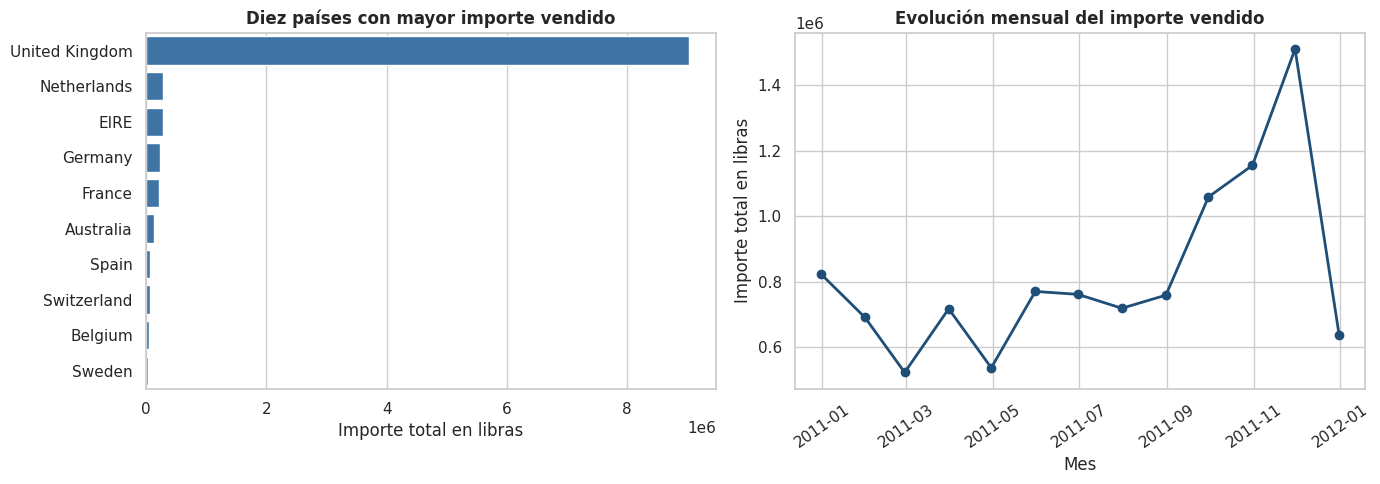

,Country,TotalAmount
0,United Kingdom,"9,025,222.08"
1,Netherlands,"285,446.34"
2,EIRE,"283,453.96"
3,Germany,"228,867.14"
4,France,"209,715.11"
5,Australia,"138,521.31"
6,Spain,"61,577.11"
7,Switzerland,"57,089.90"
8,Belgium,"41,196.34"
9,Sweden,"38,378.33"


In [8]:
# Exploración descriptiva preliminar sin cancelaciones y con importes positivos.
# Se realiza una exploración preliminar usando solo transacciones válidas
# (sin cancelaciones y con cantidades y precios positivos).
# Se analiza el importe vendido por país y su evolución mensual.

df_eda = df_raw.copy()
df_eda["EsCancelacion"] = df_eda["InvoiceNo"].astype(str).str.upper().str.startswith("C")
df_eda = df_eda[
    (~df_eda["EsCancelacion"])
    & (df_eda["Quantity"] > 0)
    & (df_eda["UnitPrice"] > 0)
].copy()
df_eda["TotalAmount"] = df_eda["Quantity"] * df_eda["UnitPrice"]

country_sales = (
    df_eda.groupby("Country", as_index=False)["TotalAmount"]
    .sum()
    .sort_values("TotalAmount", ascending=False)
    .head(10)
)

monthly_sales = (
    df_eda.set_index("InvoiceDate")
    .resample("ME")["TotalAmount"]
    .sum()
    .rename("Ventas")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=country_sales,
    y="Country",
    x="TotalAmount",
    ax=axes[0],
    color="#2E75B6",
)
axes[0].set_title("Diez países con mayor importe vendido", weight="bold")
axes[0].set_xlabel("Importe total en libras")
axes[0].set_ylabel("")

axes[1].plot(monthly_sales.index, monthly_sales.values, marker="o", color="#1F4E78", linewidth=2)
axes[1].set_title("Evolución mensual del importe vendido", weight="bold")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Importe total en libras")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_2_ventas_pais_tiempo.png", dpi=180, bbox_inches="tight")
plt.show()

display(country_sales.reset_index(drop=True))

### Hallazgos del EDA

1. El archivo tiene una escala suficiente para un proyecto de segmentación: supera medio millón de filas.
2. `CustomerID` concentra la mayor cantidad de valores faltantes y es indispensable para reunir las compras de cada cliente.
3. Existen duplicados exactos, cancelaciones y cantidades o precios no positivos.
4. La variable `InvoiceNo` permite distinguir compras de anulaciones.
5. Las distribuciones monetarias presentan valores extremos, por lo que será necesario transformar y escalar las variables antes de aplicar K-Means.
6. La actividad comercial está concentrada principalmente en el Reino Unido y cambia a lo largo del periodo observado.

## 2.3 Limpieza de datos

In [9]:
df = df_raw.copy()
cleaning_log = [{"Etapa": "Registros originales", "Registros": len(df)}]

# 1. Eliminar filas idénticas.
df = df.drop_duplicates().copy()
cleaning_log.append({"Etapa": "Sin duplicados exactos", "Registros": len(df)})

# 2. CustomerID es necesario para construir un registro por cliente.
df = df.dropna(subset=["CustomerID"]).copy()
cleaning_log.append({"Etapa": "Con CustomerID identificado", "Registros": len(df)})

# 3. Retirar cancelaciones, identificadas por la letra C al inicio de InvoiceNo.
is_cancellation = df["InvoiceNo"].astype(str).str.upper().str.startswith("C")
df = df[~is_cancellation].copy()
cleaning_log.append({"Etapa": "Sin facturas canceladas", "Registros": len(df)})

# 4. Conservar únicamente compras con cantidad y precio positivos.
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
cleaning_log.append({"Etapa": "Cantidad y precio positivos", "Registros": len(df)})

# 5. Ajustar el identificador y construir el importe de cada línea.
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

cleaning_audit = pd.DataFrame(cleaning_log)
cleaning_audit["Eliminados_en_etapa"] = (
    cleaning_audit["Registros"].shift(1) - cleaning_audit["Registros"]
).fillna(0).astype(int)
cleaning_audit["Retencion_porcentaje"] = (
    cleaning_audit["Registros"] / cleaning_audit.loc[0, "Registros"] * 100
).round(2)

display(cleaning_audit)
print(f"Dataset limpio: {len(df):,} filas")
print(f"Retención final: {len(df) / len(df_raw) * 100:.2f}%")

,Etapa,Registros,Eliminados_en_etapa,Retencion_porcentaje
0,Registros originales,541909,0,100.00
1,Sin duplicados exactos,536641,5268,99.03
2,Con CustomerID identificado,401604,135037,74.11
3,Sin facturas canceladas,392732,8872,72.47
4,Cantidad y precio positivos,392692,40,72.46


Dataset limpio: 392,692 filas
Retención final: 72.46%


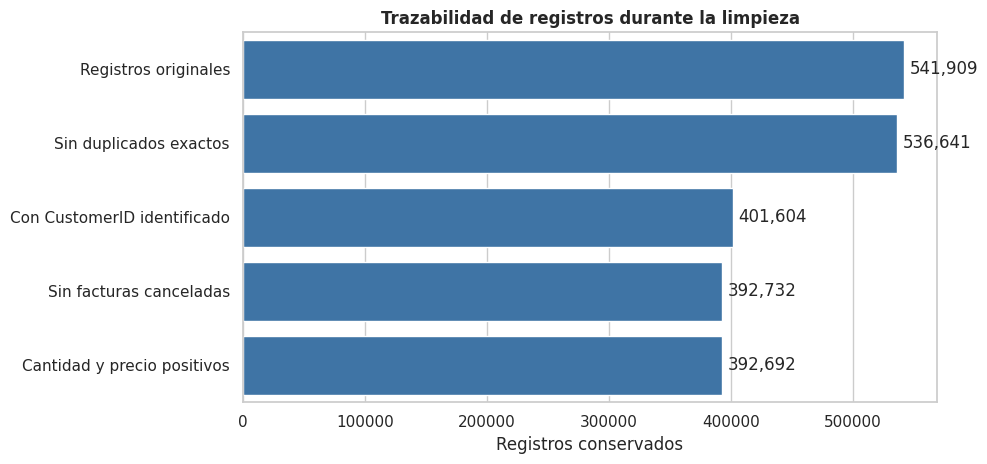

,Incidencias después de limpiar
Duplicados,0
CustomerID nulo,0
Cancelaciones,0
Cantidad no positiva,0
Precio no positivo,0


In [10]:
# Visualizar cuántos registros se conservan después de cada etapa de limpieza.
# Esto permite observar la trazabilidad y el impacto de cada filtro aplicado.
fig, ax = plt.subplots(figsize=(10, 4.8))

sns.barplot(
    data=cleaning_audit,
    x="Registros",
    y="Etapa",
    color="#2E75B6",
    ax=ax,
)

ax.set_title("Trazabilidad de registros durante la limpieza", weight="bold")
ax.set_xlabel("Registros conservados")
ax.set_ylabel("")

# Mostrar sobre cada barra la cantidad exacta de registros conservados.
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4)

plt.tight_layout()

# Guardar el gráfico generado para utilizarlo posteriormente en el informe.
plt.savefig(OUTPUT_DIR / "figura_3_trazabilidad_limpieza.png", dpi=180, bbox_inches="tight")
plt.show()

# Verificamos que después del proceso ya no existan las incidencias
# que decidimos eliminar: duplicados, clientes sin ID, cancelaciones
# y valores no positivos.

validation = pd.Series({
    "Duplicados": int(df.duplicated().sum()),
    "CustomerID nulo": int(df["CustomerID"].isna().sum()),
    "Cancelaciones": int(df["InvoiceNo"].astype(str).str.upper().str.startswith("C").sum()),
    "Cantidad no positiva": int((df["Quantity"] <= 0).sum()),
    "Precio no positivo": int((df["UnitPrice"] <= 0).sum()),
}, name="Incidencias después de limpiar")

# IMPORTANTE: se espera obtener 0 en todas las incidencias,
# confirmando que el dataset cumple con los criterios de limpieza definidos.
display(validation.to_frame())

### Justificación de la limpieza

- Los duplicados podían contabilizar dos veces la misma línea de venta.
- Los registros sin `CustomerID` no podían asignarse a un comprador concreto.
- Las cancelaciones no representan compras efectivas y alterarían la frecuencia y el valor monetario.
- Las cantidades y precios no positivos no son compatibles con el objetivo de calcular compras válidas.
- No se eliminan clientes únicamente por presentar un gasto elevado: dichos casos pueden representar compradores mayoristas reales. Su influencia se reduce posteriormente con `log1p`.

## 2.4 Preparación del dataset para modelado

In [11]:
# Se usa como referencia un día después de la transacción más reciente.
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda values: (reference_date - values.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum"),
    )
    .reset_index()
)

print(f"Fecha de referencia: {reference_date}")
print(f"Matriz RFM: {rfm.shape[0]:,} clientes y 3 variables de modelado")
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)

Fecha de referencia: 2011-12-10 12:50:00
Matriz RFM: 4,338 clientes y 3 variables de modelado


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",92.54,100.01,1.00,18.00,51.00,142.00,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02"


### Definición matemática de RFM

Para cada cliente $i$ se calculan:

$$R_i = \text{fecha de referencia} - \max(\text{fecha de compra}_{i})$$

$$F_i = \text{número de facturas únicas del cliente } i$$

$$M_i = \sum_{j=1}^{n_i}(\text{cantidad}_{ij}\times\text{precio}_{ij})$$

Un valor menor de `Recency` representa una compra más reciente. Los valores altos de `Frequency` y `Monetary` representan mayor actividad y gasto, respectivamente.

,Asimetria_original,Asimetria_log1p
Recency,1.25,-0.38
Frequency,12.07,1.21
Monetary,19.34,0.40


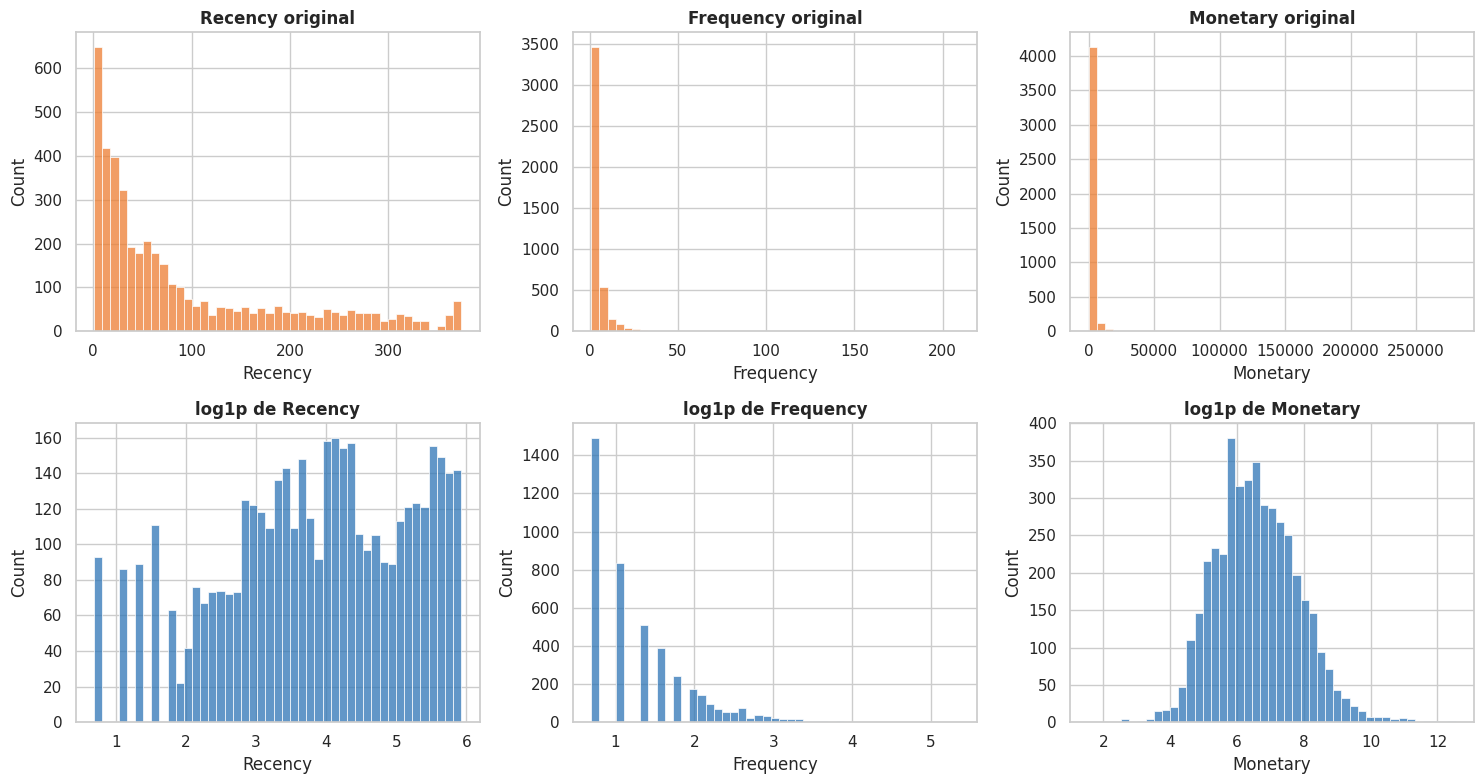

In [12]:
# Seleccionar las tres variables RFM que serán utilizadas para el modelado.
rfm_features = ["Recency", "Frequency", "Monetary"]

# Calcular la asimetría original de cada variable.
# Una asimetría alta indica que existen valores extremos que pueden influir en K-Means.
skew_before = rfm[rfm_features].skew()

# Aplicar transformación logarítmica log1p para reducir la asimetría
# y disminuir la influencia de valores extremadamente altos.
rfm_log = np.log1p(rfm[rfm_features])

# Comprobar cuánto disminuyó la asimetría después de la transformación.
skew_after = rfm_log.skew()

skewness = pd.DataFrame({
    "Asimetria_original": skew_before,
    "Asimetria_log1p": skew_after,
}).round(3)

display(skewness)


# Comparar visualmente la distribución original y transformada
# de Recency, Frequency y Monetary.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for index, variable in enumerate(rfm_features):

    # Primera fila: distribución original.
    sns.histplot(rfm[variable], bins=45, color="#ED7D31", ax=axes[0, index])
    axes[0, index].set_title(f"{variable} original", weight="bold")

    # Segunda fila: distribución después de aplicar log1p.
    sns.histplot(rfm_log[variable], bins=45, color="#2E75B6", ax=axes[1, index])
    axes[1, index].set_title(f"log1p de {variable}", weight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_4_transformacion_rfm.png", dpi=180, bbox_inches="tight")
plt.show()

# log1p no estandariza las variables; únicamente reduce su asimetría.
# La estandarización se realizará después antes de aplicar K-Means.

,Recency,Frequency,Monetary
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00


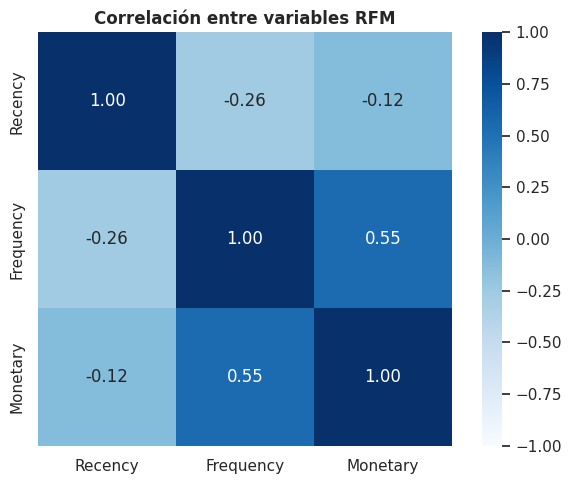

In [13]:
# StandardScaler asigna media 0 y desviación estándar 1 a cada variable.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

scaled_check = pd.DataFrame(X_scaled, columns=rfm_features).agg(["mean", "std"]).round(4)
display(scaled_check)

correlation = rfm[rfm_features].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Correlación entre variables RFM", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_5_correlacion_rfm.png", dpi=180, bbox_inches="tight")
plt.show()

### Decisiones de preparación

1. La unidad de análisis cambia de transacción a cliente.
2. Solo se utilizan RFM en el primer modelo para mantener una interpretación comercial directa.
3. Se aplica $\log(1+x)$ porque `Frequency` y `Monetary` presentan fuerte asimetría y valores extremos.
4. Se aplica `StandardScaler` porque K-Means utiliza distancias euclidianas; sin escalado, el componente monetario dominaría la distancia.
5. `CustomerID` se conserva únicamente como identificador y no participa en el entrenamiento.

## 2.5 Primer modelo de aprendizaje no supervisado

### Selección del algoritmo

Se utiliza **K-Means** porque el objetivo es obtener una partición de clientes fácil de describir mediante centroides. El algoritmo asigna cada observación al centroide más cercano y actualiza iterativamente los centroides para minimizar la suma de distancias cuadráticas dentro de los clusters, conocida como inercia.

Antes del entrenamiento definitivo se prueban valores de $k$ entre 2 y 10. La selección considera simultáneamente:

- **Inercia:** debe disminuir; se busca el punto en el que la mejora empieza a desacelerarse.
- **Silhouette:** valores más altos indican mayor cohesión y separación.
- **Davies-Bouldin:** valores más bajos indican clusters más compactos y separados.
- **Calinski-Harabasz:** valores más altos representan una mejor relación entre separación externa y dispersión interna.

In [14]:
# Probar diferentes valores de k (de 2 a 10) para determinar
# cuántos clusters son adecuados para segmentar a los clientes.
model_selection_rows = []

for k in range(2, 11):

    # Crear un modelo K-Means para cada número de clusters.
    candidate = KMeans(
        n_clusters=k,
        init="k-means++",      # Selecciona centroides iniciales de forma más eficiente.
        n_init=20,             # Ejecuta K-Means 20 veces y conserva la mejor solución.
        max_iter=300,          # Máximo de iteraciones para alcanzar la convergencia.
        random_state=SEED,     # Permite reproducir los mismos resultados.
        algorithm="lloyd",
    )

    # Entrenar el modelo con los datos RFM estandarizados
    # y obtener el cluster asignado a cada cliente.
    labels = candidate.fit_predict(X_scaled)

    # Guardar las métricas de evaluación para cada valor de k.
    model_selection_rows.append({
        "k": k,
        "Inercia": candidate.inertia_,  # Menor valor = clusters más compactos.
        "Silhouette": silhouette_score(X_scaled, labels),  # Mayor = mejor separación.
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),  # Menor = mejor.
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),  # Mayor = mejor.
    })

# Convertir los resultados en una tabla para comparar los diferentes valores de k.
k_metrics = pd.DataFrame(model_selection_rows)

display(k_metrics.round(4))

# no se elige k utilizando una sola métrica.
# Se comparan estas métricas junto con el método del codo
# y la interpretabilidad de los segmentos obtenidos.

,k,Inercia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,"6,483.59",0.43,0.89,"4,367.32"
1,3,"4,869.49",0.34,1.05,"3,625.30"
2,4,"3,938.60",0.34,1.01,"3,328.92"
3,5,"3,296.71",0.32,0.99,"3,192.98"
4,6,"2,855.53",0.31,1.02,"3,082.28"
5,7,"2,548.82",0.31,0.98,"2,963.79"
6,8,"2,336.34",0.30,0.99,"2,827.07"
7,9,"2,156.01",0.28,1.02,"2,725.20"
8,10,"2,000.57",0.28,1.02,"2,647.38"


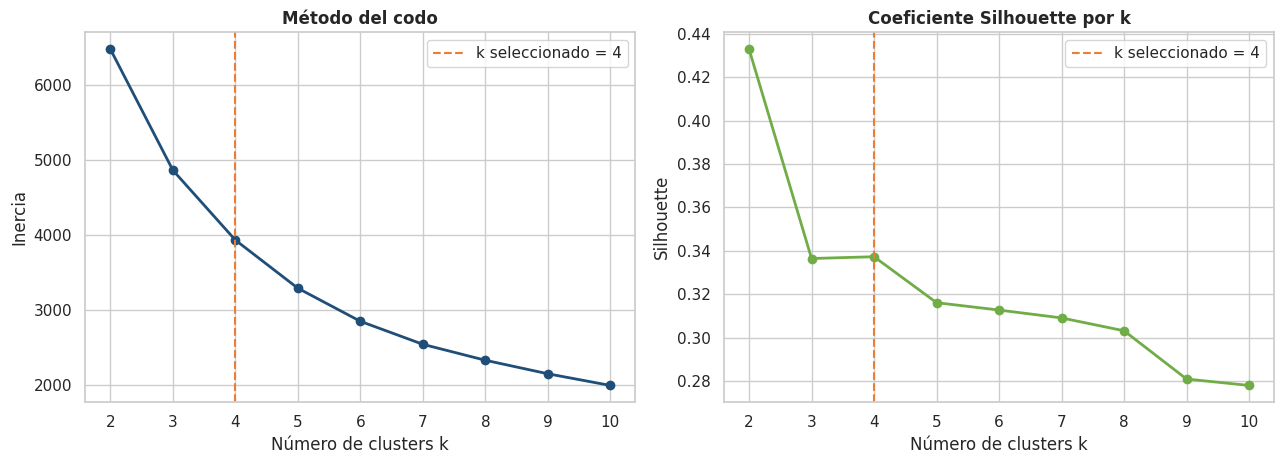

In [15]:
# Crear dos gráficos para comparar los principales criterios
# utilizados en la selección del número de clusters.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# MÉTODO DEL CODO:
# Muestra cómo disminuye la inercia al aumentar el número de clusters.
# Se busca un punto donde agregar más clusters ya no produzca una mejora tan grande.
axes[0].plot(k_metrics["k"], k_metrics["Inercia"], marker="o", color="#1F4E78", linewidth=2)

# Marcar k=4 como el número de clusters seleccionado.
axes[0].axvline(4, color="#ED7D31", linestyle="--", label="k seleccionado = 4")

axes[0].set_title("Método del codo", weight="bold")
axes[0].set_xlabel("Número de clusters k")
axes[0].set_ylabel("Inercia")
axes[0].legend()


# COEFICIENTE SILHOUETTE:
# Evalúa qué tan bien agrupados y separados se encuentran los clientes.
# Valores más altos indican una mejor separación entre clusters.
axes[1].plot(k_metrics["k"], k_metrics["Silhouette"], marker="o", color="#70AD47", linewidth=2)

axes[1].axvline(4, color="#ED7D31", linestyle="--", label="k seleccionado = 4")

axes[1].set_title("Coeficiente Silhouette por k", weight="bold")
axes[1].set_xlabel("Número de clusters k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_6_seleccion_k.png", dpi=180, bbox_inches="tight")
plt.show()

# IMPORTANTE: k=4 no tiene el mayor Silhouette (k=2 es mayor).
# Se selecciona k=4 considerando en conjunto el método del codo,
# las métricas obtenidas y la interpretabilidad de los segmentos.

### Justificación de k igual a 4

El valor $k=2$ obtiene el mayor Silhouette, pero produce una separación muy general entre clientes de bajo y alto compromiso. El gráfico de inercia muestra una desaceleración visible alrededor de cuatro clusters. Se selecciona $k=4$ porque conserva una separación interna aceptable y ofrece cuatro perfiles comercialmente diferenciables: inactivos de bajo valor, compradores habituales, clientes recientes en desarrollo y clientes de alto valor. Esta decisión equilibra calidad geométrica e interpretabilidad; no se afirma que sea la única partición posible.

In [16]:
# Crear el modelo K-Means definitivo utilizando los 4 clusters seleccionados.
kmeans = KMeans(
    n_clusters=4,          # Número de segmentos que se desean formar.
    init="k-means++",      # Inicialización eficiente de los centroides.
    n_init=20,             # Ejecuta el algoritmo 20 veces y conserva la mejor solución.
    max_iter=300,          # Máximo de iteraciones para alcanzar la convergencia.
    random_state=SEED,     # Permite reproducir los resultados.
    algorithm="lloyd",
)

# Entrenar K-Means con las variables RFM transformadas y estandarizadas.
# El modelo asigna automáticamente un cluster (0, 1, 2 o 3) a cada cliente.
rfm["Cluster"] = kmeans.fit_predict(X_scaled)


# Calcular las métricas del modelo final para evaluar
# la compactación y separación de los 4 clusters obtenidos.
selected_metrics = pd.Series({
    "k": 4,
    "Inercia": kmeans.inertia_,
    "Silhouette": silhouette_score(X_scaled, rfm["Cluster"]),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, rfm["Cluster"]),
    "Calinski-Harabasz": calinski_harabasz_score(X_scaled, rfm["Cluster"]),
}, name="Resultado")

display(selected_metrics.to_frame())


# PERFILAMIENTO DE LOS CLUSTERS:
# Agrupar los clientes según el cluster asignado y calcular
# estadísticas de Recency, Frequency y Monetary para cada segmento.
cluster_summary = (
    rfm.groupby("Cluster")
    .agg(
        Clientes=("CustomerID", "count"),
        Recencia_mediana=("Recency", "median"),
        Frecuencia_mediana=("Frequency", "median"),
        Monetario_mediano=("Monetary", "median"),
        Recencia_media=("Recency", "mean"),
        Frecuencia_media=("Frequency", "mean"),
        Monetario_medio=("Monetary", "mean"),
    )
)

# Calcular qué porcentaje del total de clientes pertenece a cada cluster.
cluster_summary["Porcentaje"] = cluster_summary["Clientes"] / len(rfm) * 100

display(cluster_summary.round(2))

# IMPORTANTE: K-Means únicamente genera los grupos y les asigna números (0, 1, 2, 3).
# La interpretación y el nombre comercial de cada segmento se realiza después,
# analizando sus valores originales de Recency, Frequency y Monetary.

,Resultado
k,4.00
Inercia,"3,938.60"
Silhouette,0.34
Davies-Bouldin,1.01
Calinski-Harabasz,"3,328.92"


,Clientes,Recencia_mediana,Frecuencia_mediana,Monetario_mediano,Recencia_media,Frecuencia_media,Monetario_medio,Porcentaje
Cluster,,,,,,,,
0,1617,177.00,1.00,298.40,182.63,1.32,347.85,37.28
1,1173,55.00,4.00,"1,341.65",70.13,4.11,"1,804.82",27.04
2,839,17.00,2.00,466.70,18.21,2.14,543.06,19.34
3,709,8.00,10.00,"3,722.82",12.08,13.79,"8,112.93",16.34


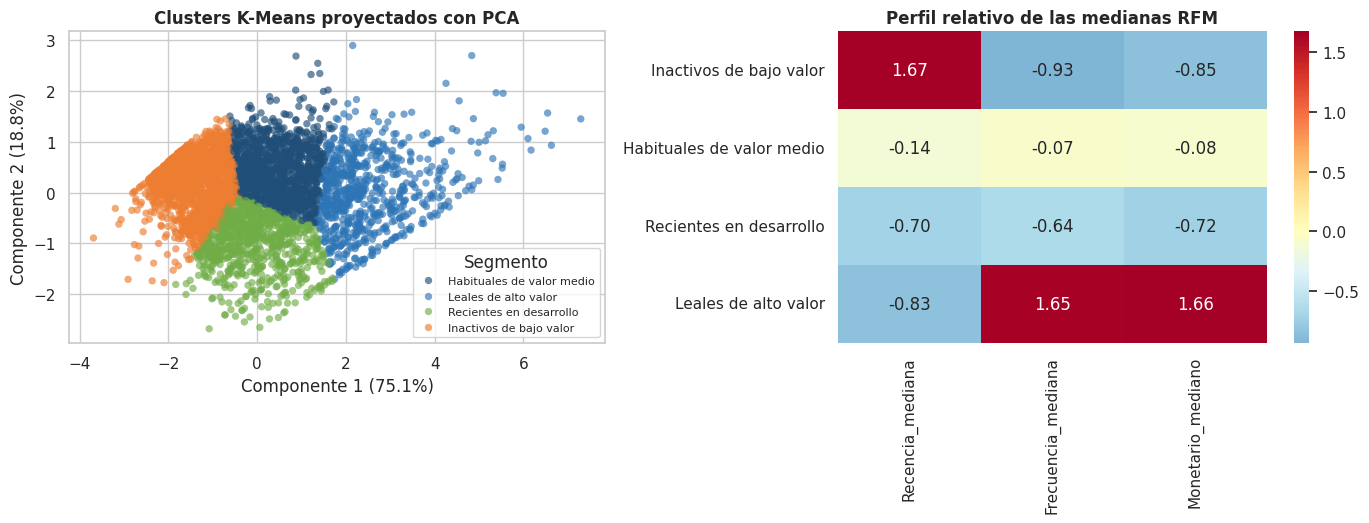

In [17]:
# Asignar un nombre descriptivo a cada cluster según el comportamiento
# observado en sus valores de Recency, Frequency y Monetary.
cluster_names = {
    0: "Inactivos de bajo valor",
    1: "Habituales de valor medio",
    2: "Recientes en desarrollo",
    3: "Leales de alto valor",
}

# Agregar al dataset el nombre correspondiente al cluster de cada cliente.
rfm["Segmento"] = rfm["Cluster"].map(cluster_names)


# PCA se utiliza para reducir las 3 variables RFM a 2 componentes
# y así poder visualizar gráficamente los clusters.
pca = PCA(n_components=2, random_state=SEED)
coordinates = pca.fit_transform(X_scaled)

rfm["PC1"] = coordinates[:, 0]
rfm["PC2"] = coordinates[:, 1]


# Crear dos visualizaciones para interpretar los segmentos obtenidos.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))

# GRÁFICO PCA:
# Cada punto representa un cliente y el color indica el segmento
# al que fue asignado por K-Means.
sns.scatterplot(
    data=rfm,
    x="PC1",
    y="PC2",
    hue="Segmento",
    palette=COLORS,
    s=28,
    alpha=0.65,
    linewidth=0,
    ax=axes[0],
)

axes[0].set_title("Clusters K-Means proyectados con PCA", weight="bold")
axes[0].set_xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
axes[0].set_ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
axes[0].legend(title="Segmento", fontsize=8)


# Seleccionar las medianas RFM de cada cluster para comparar
# el comportamiento típico de los segmentos.
profile = cluster_summary[[
    "Recencia_mediana", "Frecuencia_mediana", "Monetario_mediano"
]].copy()

profile.index = [cluster_names[index] for index in profile.index]

# Estandarizar las medianas para poder comparar las tres variables
# en una misma escala dentro del mapa de calor.
profile_z = (profile - profile.mean()) / profile.std(ddof=0)

# MAPA DE CALOR:
# Permite identificar qué variables RFM están relativamente
# altas o bajas en cada segmento.
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, ax=axes[1])

axes[1].set_title("Perfil relativo de las medianas RFM", weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_7_clusters_resultado.png", dpi=180, bbox_inches="tight")
plt.show()

# IMPORTANTE: PCA NO crea los clusters; los clusters ya fueron generados por K-Means.
# PCA se utiliza únicamente para reducir dimensiones y facilitar su visualización.

### Interpretación inicial de los clusters

- **Cluster 0 — Inactivos de bajo valor:** es el grupo más numeroso; presenta alta recencia, una sola compra típica y gasto bajo. Representa clientes alejados de la tienda.
- **Cluster 1 — Habituales de valor medio:** combina recencia intermedia con aproximadamente cuatro compras y un gasto claramente superior al de los grupos 0 y 2.
- **Cluster 2 — Recientes en desarrollo:** realizó compras hace poco, aunque su frecuencia y gasto todavía son moderados. Puede evolucionar hacia una relación más sólida.
- **Cluster 3 — Leales de alto valor:** reúne a los compradores más recientes, frecuentes y valiosos. Es el grupo de mayor intensidad comercial.

Los nombres son interpretaciones analíticas posteriores al entrenamiento; no son etiquetas originales del dataset. La evaluación comparativa completa se desarrolla a continuación.

In [18]:
# Exportar resultados reproducibles utilizados por el informe.
cleaning_audit.to_csv(OUTPUT_DIR / "auditoria_limpieza.csv", index=False)
k_metrics.to_csv(OUTPUT_DIR / "metricas_seleccion_k.csv", index=False)
cluster_summary.round(4).to_csv(OUTPUT_DIR / "resumen_clusters.csv")
rfm.to_csv(OUTPUT_DIR / "clientes_rfm_con_cluster.csv", index=False)

print("Archivos generados:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

Archivos generados:
- auditoria_limpieza.csv
- clientes_rfm_con_cluster.csv
- figura_1_calidad_datos.png
- figura_2_ventas_pais_tiempo.png
- figura_3_trazabilidad_limpieza.png
- figura_4_transformacion_rfm.png
- figura_5_correlacion_rfm.png
- figura_6_seleccion_k.png
- figura_7_clusters_resultado.png
- metricas_seleccion_k.csv
- resumen_clusters.csv


## 2.6 Segundo modelo de aprendizaje no supervisado
Se mantiene K-Means y se cambia su hiperparámetro principal de cuatro a dos clusters. Esta opción está expresamente permitida por la guía. La hipótesis es que una partición más general mejora la separación interna, aunque pierde detalle comercial. Se conserva la misma matriz de 4 338 clientes, transformación, escalador y demás parámetros para aislar el efecto de k. No se afirma que se hayan aplicado dos algoritmos distintos.

In [19]:
# C26 — Entrenamiento del segundo modelo y perfiles RFM
kmeans_2 = KMeans(n_clusters=2, init="k-means++", n_init=20,
                  max_iter=300, random_state=SEED, algorithm="lloyd")
labels_2 = kmeans_2.fit_predict(X_scaled)
rfm["Cluster_2"] = labels_2
summary_2 = rfm.groupby("Cluster_2").agg(
    Clientes=("CustomerID", "count"),
    Recencia_mediana=("Recency", "median"),
    Frecuencia_mediana=("Frequency", "median"),
    Monetario_mediano=("Monetary", "median"))
summary_2["Porcentaje"] = summary_2["Clientes"] / len(rfm) * 100
# Los nombres se asignan después del entrenamiento a partir de las medianas.
high_cluster = int(summary_2["Monetario_mediano"].idxmax())
names_2 = {int(c): ("Activos de mayor valor" if c == high_cluster
                     else "Menor actividad y valor") for c in summary_2.index}
summary_2["Segmento"] = summary_2.index.map(names_2)
rfm["Segmento_2"] = rfm["Cluster_2"].map(names_2)
display(summary_2.round(2))

,Clientes,Recencia_mediana,Frecuencia_mediana,Monetario_mediano,Porcentaje,Segmento
Cluster_2,,,,,,
0,2672,96.00,1.00,363.08,61.60,Menor actividad y valor
1,1666,16.00,6.00,"2,061.08",38.40,Activos de mayor valor


**Resultados e interpretación:** el cluster 0 reúne 2 672 clientes (61.60%), con medianas R=96 días, F=1 factura y M=£363.08. Se denomina Menor actividad y valor. El cluster 1 reúne 1 666 clientes (38.40%), con medianas R=16, F=6 y M=£2 061.08; se denomina Activos de mayor valor. Son nombres posteriores al entrenamiento que describen el perfil típico, sin imponer umbrales individuales ni predecir compras futuras.

## 2.7 Evaluación de cada modelo

In [20]:
# C27 — Evaluación sobre el mismo espacio RFM de tres dimensiones
def evaluar(modelo, etiquetas, nombre):
    return {"Modelo": nombre, "k": modelo.n_clusters,
            "Silhouette": silhouette_score(X_scaled, etiquetas),
            "Davies_Bouldin": davies_bouldin_score(X_scaled, etiquetas),
            "Calinski_Harabasz": calinski_harabasz_score(X_scaled, etiquetas),
            "Inercia": modelo.inertia_}

comparison = pd.DataFrame([
    evaluar(kmeans, rfm["Cluster"], "K-Means k=4"),
    evaluar(kmeans_2, labels_2, "K-Means k=2")])
display(comparison.round(4))
print(f"Varianza conservada por PCA 2D: {pca.explained_variance_ratio_.sum():.2%}")
print("Las métricas se calculan en 3D; PCA se utiliza solo para visualizar.")

,Modelo,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia
0,K-Means k=4,4,0.34,1.01,"3,328.92","3,938.60"
1,K-Means k=2,2,0.43,0.89,"4,367.32","6,483.59"


Varianza conservada por PCA 2D: 93.87%
Las métricas se calculan en 3D; PCA se utiliza solo para visualizar.


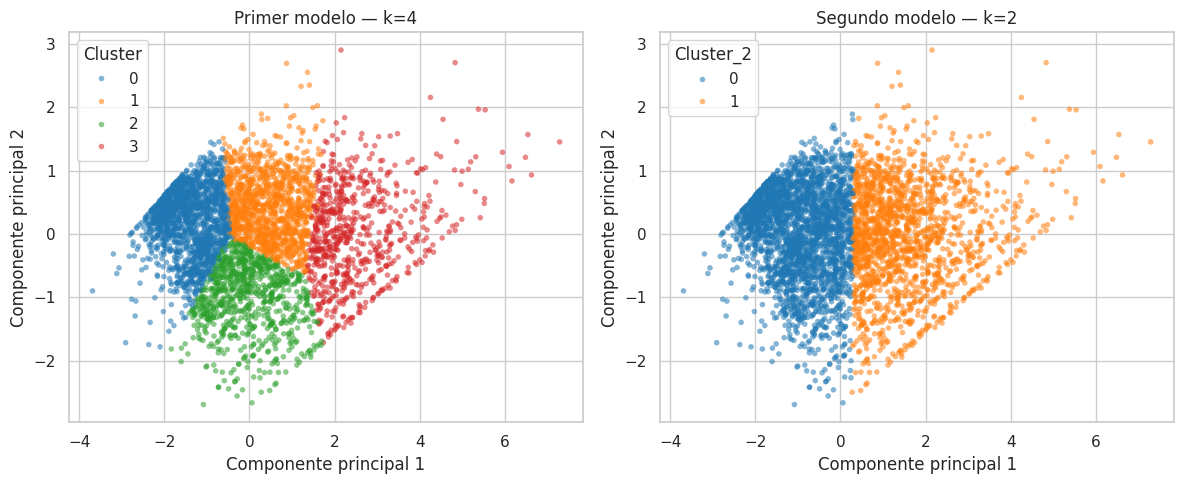

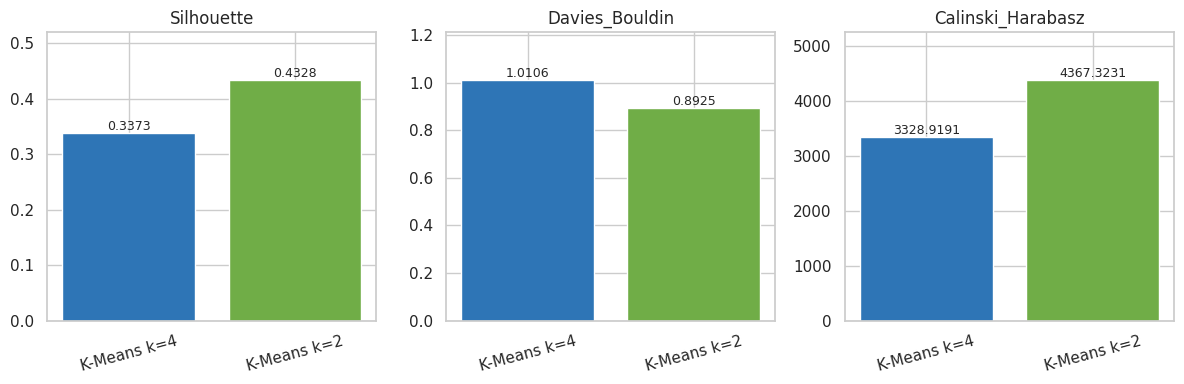

In [21]:
# C28 — Visualización comparable de los dos modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, column, title in zip(axes, ["Cluster", "Cluster_2"],
                            ["Primer modelo — k=4", "Segundo modelo — k=2"]):
    sns.scatterplot(data=rfm, x="PC1", y="PC2", hue=column,
                    palette="tab10", s=16, alpha=.55, linewidth=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_8_comparacion_pca.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]):
    ax.bar(comparison["Modelo"], comparison[metric], color=["#2E75B6", "#70AD47"])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
    ax.margins(y=.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_9_metricas_comparadas.png", dpi=160)
plt.show()

,mean,min,max
Cluster,,,
0,0.48,0.03,0.65
1,0.35,-0.04,0.57


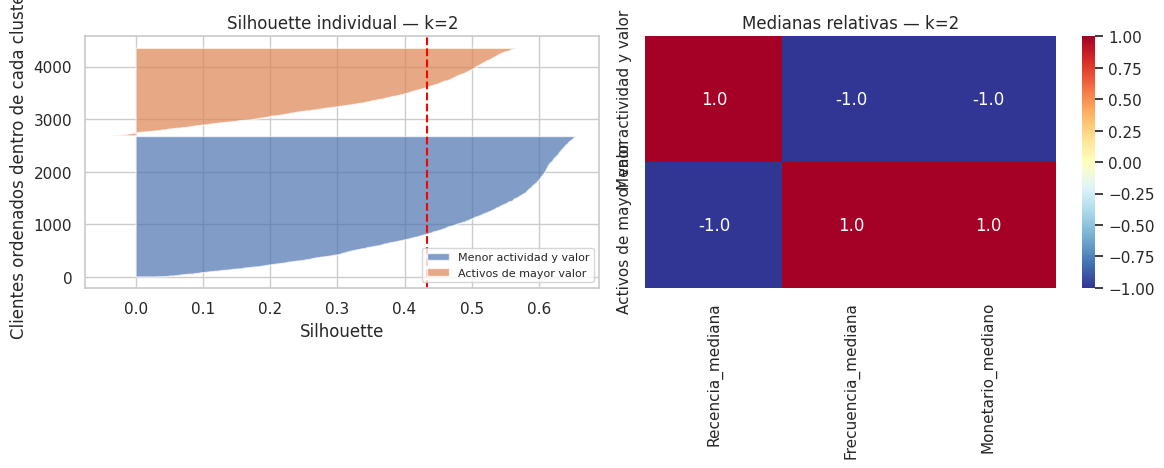

In [22]:
# C29 — Perfil y Silhouette por cluster del segundo modelo
from sklearn.metrics import silhouette_samples
sil_samples = silhouette_samples(X_scaled, labels_2)
sil_by_cluster = pd.DataFrame({"Cluster": labels_2, "Silhouette": sil_samples})
display(sil_by_cluster.groupby("Cluster")["Silhouette"].agg(["mean", "min", "max"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
bottom = 10
for c in sorted(names_2):
    values = np.sort(sil_samples[labels_2 == c])
    top = bottom + len(values)
    axes[0].fill_betweenx(np.arange(bottom, top), 0, values, alpha=.7, label=names_2[c])
    bottom = top + 10
axes[0].axvline(comparison.loc[1, "Silhouette"], color="red", linestyle="--")
axes[0].set_title("Silhouette individual — k=2")
axes[0].set_xlabel("Silhouette")
axes[0].set_ylabel("Clientes ordenados dentro de cada cluster")
axes[0].legend(fontsize=8)
profile_2 = summary_2[["Recencia_mediana", "Frecuencia_mediana", "Monetario_mediano"]]
profile_z2 = (profile_2 - profile_2.mean()) / profile_2.std(ddof=0)
profile_z2.index = [names_2[int(c)] for c in profile_z2.index]
sns.heatmap(profile_z2, annot=True, fmt=".1f", cmap="RdYlBu_r", center=0, ax=axes[1])
axes[1].set_title("Medianas relativas — k=2")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_10_silhouette_perfiles.png", dpi=160)
plt.show()

## 2.8 Comparación de modelos
**Criterio de selección:** priorizar Silhouette mayor, contrastado con Davies-Bouldin menor y Calinski-Harabasz mayor; valorar adicionalmente la interpretación y el uso en la app. La inercia no determina el ganador entre distintos k porque normalmente disminuye al añadir grupos. No se calculan accuracy, precision ni recall: no hay etiquetas de referencia.

La comparación es exploratoria y se efectúa sobre los mismos datos usados para ajustar los modelos. No demuestra capacidad predictiva futura ni mejora causal de ventas. Cuatro segmentos ofrecen mayor detalle comercial; dos segmentos pueden tener mejor geometría interna sin reemplazar todas las necesidades de marketing.

**Resultado calculado:** k=2 obtiene Silhouette 0.4328, Davies-Bouldin 0.8925 y Calinski-Harabasz 4 367.3231, frente a 0.3373, 1.0106 y 3 328.9191 de k=4. Se selecciona k=2 por mejor calidad interna en las tres métricas. La inercia menor de k=4 es esperable por tener más centroides.

**Interpretación del equipo:** dos grupos describen patrones generales más separados; cuatro distinguen perfiles comerciales más específicos. La tabla cruzada indica que todos los inactivos pasan al grupo de menor actividad y todos los leales al grupo activo, mientras que los habituales y recientes se distribuyen entre ambos. No se demuestra superioridad comercial ni estabilidad en otro periodo.

In [23]:
# C30 — Selección y tabla de correspondencia entre particiones
winner = comparison.sort_values("Silhouette", ascending=False).iloc[0]
best_model = kmeans_2 if int(winner["k"]) == 2 else kmeans
best_labels = labels_2 if int(winner["k"]) == 2 else rfm["Cluster"].to_numpy()
best_names = names_2 if int(winner["k"]) == 2 else cluster_names
print("Modelo seleccionado:", winner["Modelo"])
print("Criterio principal: Silhouette; contrastar DB y CH en C27.")
cross = pd.crosstab(rfm["Segmento"], rfm["Segmento_2"])
display(cross)
comparison.to_csv(OUTPUT_DIR / "comparacion_modelos.csv", index=False)
summary_2.to_csv(OUTPUT_DIR / "perfiles_k2.csv")
cross.to_csv(OUTPUT_DIR / "correspondencia_segmentos.csv")

Modelo seleccionado: K-Means k=2
Criterio principal: Silhouette; contrastar DB y CH en C27.


Segmento_2,Activos de mayor valor,Menor actividad y valor
Segmento,,
Habituales de valor medio,688,485
Inactivos de bajo valor,0,1617
Leales de alto valor,709,0
Recientes en desarrollo,269,570


## 2.9 Despliegue del mejor modelo con Streamlit
La app permite consultar clientes históricos y asignar un segmento a nuevos valores RFM. Se conserva el escalador ya ajustado y se aplica `log1p` antes de `predict`. No se vuelve a entrenar por cada consulta. Recency se ingresa en días, Frequency en facturas distintas y Monetary en libras esterlinas, sobre una ventana comparable al año histórico.

Un cliente sin compras no pertenece a la población de entrenamiento. Los valores fuera del rango histórico se advierten al usuario; el cluster no es una probabilidad ni una garantía de comportamiento futuro.

In [24]:
# C31 — Exportación del modelo y artefactos de la app
import joblib
import sklearn
import platform
import json
APP_DIR = Path("proyecto_streamlit_online_retail")
APP_DIR.mkdir(exist_ok=True)
app_clients = rfm[["CustomerID"] + rfm_features + ["PC1", "PC2"]].copy()
app_clients["Cluster"] = best_labels
app_clients["Segmento"] = app_clients["Cluster"].map(best_names)
app_clients.to_csv(APP_DIR / "clientes.csv", index=False)
profiles = app_clients.groupby("Cluster")[rfm_features].median()
profiles["Clientes"] = app_clients.groupby("Cluster").size()
profiles["Segmento"] = profiles.index.map(best_names)
profiles.reset_index().to_csv(APP_DIR / "perfiles.csv", index=False)
comparison.to_csv(APP_DIR / "metricas.csv", index=False)
bundle = {"model": best_model, "scaler": scaler, "pca": pca,
          "features": rfm_features, "names": best_names,
          "reference_date": str(reference_date),
          "min": rfm[rfm_features].min().to_dict(),
          "max": rfm[rfm_features].max().to_dict(),
          "sklearn_version": sklearn.__version__}
joblib.dump(bundle, APP_DIR / "modelo.joblib")
versions = {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
(APP_DIR / "versiones.json").write_text(json.dumps(versions, indent=2))
print("Modelo guardado:", winner["Modelo"])
display(profiles.round(2))
print("Artefactos preparados en", APP_DIR.resolve())

Modelo guardado: K-Means k=2


,Recency,Frequency,Monetary,Clientes,Segmento
Cluster,,,,,
0,96.00,1.00,363.08,2672,Menor actividad y valor
1,16.00,6.00,"2,061.08",1666,Activos de mayor valor


Artefactos preparados en /content/proyecto_streamlit_online_retail


In [25]:
# C32 — Generación de app.py; capturar los bloques A, B, C y D indicados
APP_CODE = r"""from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

st.set_page_config(page_title="Segmentación de clientes RFM", layout="wide")
BASE = Path(__file__).resolve().parent

# CAPTURA A — Carga del modelo entrenado y datos históricos
@st.cache_resource
def cargar_modelo():
    return joblib.load(BASE / "modelo.joblib")

@st.cache_data
def cargar_tablas():
    return (pd.read_csv(BASE / "clientes.csv", dtype={"CustomerID": str}),
            pd.read_csv(BASE / "perfiles.csv"), pd.read_csv(BASE / "metricas.csv"))

# CAPTURA B — Preprocesamiento e inferencia sin reentrenamiento
def asignar(bundle, valores):
    fila = pd.DataFrame([valores], columns=bundle["features"])
    x = bundle["scaler"].transform(np.log1p(fila))
    cluster = int(bundle["model"].predict(x)[0])
    punto = bundle["pca"].transform(x)[0]
    distancia = float(bundle["model"].transform(x)[0, cluster])
    return cluster, punto, distancia

try:
    bundle = cargar_modelo()
    clientes, perfiles, metricas = cargar_tablas()
except (FileNotFoundError, ValueError) as e:
    st.error("No se pudieron cargar los artefactos. Ejecuta el cuaderno completo y coloca sus archivos junto a app.py.")
    st.stop()

st.title("Segmentación de clientes de comercio electrónico")
st.write("Consulta el comportamiento histórico de un cliente o ingresa sus valores RFM para identificar el segmento más cercano.")
st.caption(f"Online Retail · {len(clientes):,} clientes · K-Means k={bundle['model'].n_clusters} · Fecha de referencia histórica: {bundle['reference_date']}")

# CAPTURA C — Formulario y selección de un registro existente
modo = st.radio("Modo de consulta", ["Cliente existente", "Ingresar valores RFM"], horizontal=True)
if modo == "Cliente existente":
    cid = st.selectbox("CustomerID", clientes["CustomerID"].tolist())
    fila = clientes.loc[clientes["CustomerID"] == cid].iloc[0]
    valores = fila[bundle["features"]].astype(float).tolist()
    st.dataframe(pd.DataFrame([dict(zip(bundle["features"], valores))]), hide_index=True)
    mostrar = True
else:
    st.write("Usa una ventana de observación comparable al año del dataset. Monetary se expresa en libras esterlinas y Frequency cuenta facturas distintas.")
    with st.form("rfm"):
        r = st.number_input("Recency — días desde la última compra", min_value=0, value=30, step=1)
        f = st.number_input("Frequency — facturas distintas", min_value=1, value=3, step=1)
        m = st.number_input("Monetary — gasto acumulado en GBP", min_value=0.01, value=1000.0, step=10.0)
        mostrar = st.form_submit_button("Asignar segmento")
    valores = [r, f, m]

# CAPTURA D — Resultado, perfil y visualización de la consulta
if mostrar:
    if not np.isfinite(valores).all():
        st.error("Ingresa valores numéricos finitos.")
        st.stop()
    fuera = [v for v, x in zip(bundle["features"], valores)
             if x < bundle["min"][v] or x > bundle["max"][v]]
    if fuera:
        st.warning("Valores fuera del rango histórico: " + ", ".join(fuera) + ". La asignación requiere cautela.")
    cluster, punto, distancia = asignar(bundle, valores)
    st.success(f"Cluster {cluster} — {bundle['names'][cluster]}")
    st.caption(f"Distancia al centroide en el espacio estandarizado: {distancia:.3f}. No representa una probabilidad.")
    st.subheader("Perfil típico del segmento")
    st.dataframe(perfiles[perfiles["Cluster"] == cluster], hide_index=True)
    st.subheader("Ubicación del cliente en los segmentos")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for c, grupo in clientes.groupby("Cluster"):
        ax.scatter(grupo["PC1"], grupo["PC2"], s=10, alpha=.3, label=bundle["names"][int(c)])
    ax.scatter(punto[0], punto[1], marker="*", c="black", s=220, edgecolors="white", label="Cliente consultado")
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.legend(fontsize=8)
    fig.tight_layout()
    st.pyplot(fig)
    plt.close(fig)
    st.caption(f"PCA conserva {bundle['pca'].explained_variance_ratio_.sum():.1%} de la varianza. El cluster se calcula en las tres variables RFM.")

st.subheader("Evaluación de los modelos")
st.dataframe(metricas.round(4), hide_index=True)
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, col in zip(axes, ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]):
    ax.bar(metricas["Modelo"], metricas[col], color=["#2E75B6", "#70AD47"])
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
st.pyplot(fig)
plt.close(fig)
st.caption("Mayor Silhouette y Calinski-Harabasz, y menor Davies-Bouldin, favorecen la calidad interna. La comparación es exploratoria sobre el dataset histórico.")
st.subheader("Perfiles de todos los segmentos")
st.dataframe(perfiles, hide_index=True)
st.download_button("Descargar clientes segmentados", clientes.to_csv(index=False).encode("utf-8"), "clientes_segmentados.csv", "text/csv")
st.info("Los segmentos resumen compras de 2010–2011. No indican la situación actual de esas personas ni garantizan resultados comerciales futuros.")
"""
(APP_DIR / "app.py").write_text(APP_CODE, encoding="utf-8")
print("app.py creado correctamente")

app.py creado correctamente


In [26]:
# C33 — Dependencias, instrucciones y paquete para lanzar la aplicación
import importlib.metadata as metadata
import shutil
packages = ["numpy", "pandas", "scikit-learn", "joblib", "matplotlib", "streamlit"]
requirements = "\n".join(f"{name}=={metadata.version(name)}" for name in packages) + "\n"
(APP_DIR / "requirements.txt").write_text(requirements)
instructions = """# Aplicación de segmentación Online Retail

Requiere Python 3.12. Extraer todos los archivos juntos.
En una terminal, dentro de esta carpeta:
python -m pip install -r requirements.txt
python -m streamlit run app.py
Abrir http://localhost:8501 en el navegador de esa computadora.

Para Streamlit Community Cloud: subir esta carpeta completa a un repositorio
de GitHub, crear una app en https://share.streamlit.io, seleccionar repositorio,
rama y app.py; elegir Python 3.12 y desplegar. Guardar la URL real resultante.
Si la carpeta está en un subdirectorio, indicar esa ruta de app.py.
El modelo joblib requiere las versiones de requirements.txt.

Uso: seleccionar un cliente existente o ingresar R (días), F (facturas)
y M (GBP) y pulsar Asignar segmento. Consultar perfil, ubicación PCA y métricas.
No cargar modelos joblib de terceros no confiables.

Entrega académica: tomar capturas de la app funcionando, anotar URL real
si se publica y subir el ipynb a Google Colab compartiéndolo con la docente.
La URL localhost solo funciona en la computadora donde se inicia la app.
"""
(APP_DIR / "README.md").write_text(instructions, encoding="utf-8")
shutil.make_archive(str(APP_DIR), "zip", APP_DIR)
print("Paquete generado:", APP_DIR.with_suffix(".zip").resolve())
print("Iniciar: python -m streamlit run proyecto_streamlit_online_retail/app.py")
print("Colab: descargar el ZIP y ejecutarlo en la computadora local o publicar en Community Cloud.")

Paquete generado: /content/proyecto_streamlit_online_retail.zip
Iniciar: python -m streamlit run proyecto_streamlit_online_retail/app.py
Colab: descargar el ZIP y ejecutarlo en la computadora local o publicar en Community Cloud.


In [27]:
# C34 — Verificación de exportación y consulta de ejemplo
restored = joblib.load(APP_DIR / "modelo.joblib")
restored_x = restored["scaler"].transform(np.log1p(rfm[rfm_features]))
assert np.array_equal(restored["model"].predict(restored_x), best_labels)
ejemplo = pd.DataFrame([[30, 3, 1000.0]], columns=rfm_features)
ejemplo_x = restored["scaler"].transform(np.log1p(ejemplo))
ejemplo_cluster = int(restored["model"].predict(ejemplo_x)[0])
print("Verificado: modelo exportado conserva todas las asignaciones históricas.")
print("Ejemplo R=30, F=3, M=1000 GBP:", ejemplo_cluster, best_names[ejemplo_cluster])
print("La comprobación de interfaz se realiza al lanzar app.py o mediante AppTest.")

Verificado: modelo exportado conserva todas las asignaciones históricas.
Ejemplo R=30, F=3, M=1000 GBP: 1 Activos de mayor valor
La comprobación de interfaz se realiza al lanzar app.py o mediante AppTest.


## 3 Conclusiones
La limpieza y agregación permiten pasar de líneas de venta a clientes identificados. RFM resume recencia, repetición y gasto sin necesitar etiquetas previas. La transformación logarítmica y la estandarización limitan la influencia de escalas y asimetrías.

Las métricas de C27 y la correspondencia de C30 permiten sustentar la selección entre k=4 y k=2. Una mejor separación interna no implica necesariamente mayor detalle para campañas. La app conserva el procesamiento del modelo seleccionado y ofrece consulta, inferencia y gráficos.

Los resultados están limitados al periodo y mercado de Online Retail. Para uso real deben validarse con datos recientes, comprobar estabilidad temporal y medir el efecto de las acciones comerciales.

## 4 Link del cuaderno en Google Colab
Sube este archivo a https://colab.research.google.com mediante **Archivo → Subir cuaderno**. En **Compartir**, agrega a la docente con acceso de lectura y copia el enlace real. Añádelo al informe. No se ha generado un enlace de Colab desde este entorno.

## Referencias
- Chen, D. (2015). Online Retail. UCI. https://doi.org/10.24432/C5BW33
- Chen, D., Sain, S. L., y Guo, K. (2012). RFM model-based customer segmentation. https://doi.org/10.1057/dbm.2012.17
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. https://jmlr.org/papers/v12/pedregosa11a.html
- Scikit-learn. KMeans y métricas de clustering. https://scikit-learn.org/stable/modules/clustering.html
- Streamlit. Instalación y despliegue. https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app/deploy
